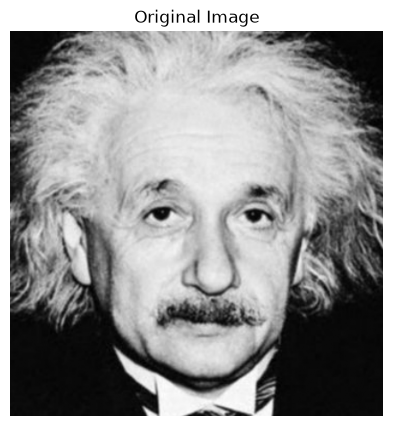

In [3]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv.imread("Images/einstein.png", cv.IMREAD_GRAYSCALE)
assert img is not None

plt.figure(figsize=(6, 5))
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

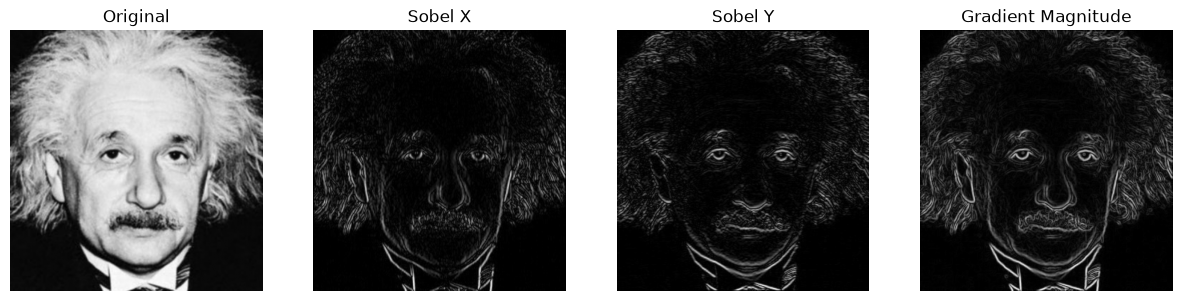

In [5]:
img_float = img.astype(np.float32)

sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobel_y = np.array([
    [-1, -2, -1],
    [0, 0, 0],
    [1, 2, 1]
], dtype=np.float32)

gx_cv = cv.filter2D(img_float, cv.CV_32F, sobel_x)
gy_cv = cv.filter2D(img_float, cv.CV_32F, sobel_y)

magnitude_cv = np.sqrt(gx_cv**2 + gy_cv**2)

magnitude_cv_display = cv.normalize(
    magnitude_cv, None, 0, 255, cv.NORM_MINMAX
).astype(np.uint8)

plt.figure(figsize=(15, 4))

plt.subplot(1, 4, 1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(np.abs(gx_cv), cmap="gray")
plt.title("Sobel X")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(np.abs(gy_cv), cmap="gray")
plt.title("Sobel Y")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(magnitude_cv_display, cmap="gray")
plt.title("Gradient Magnitude")
plt.axis("off")

plt.show()

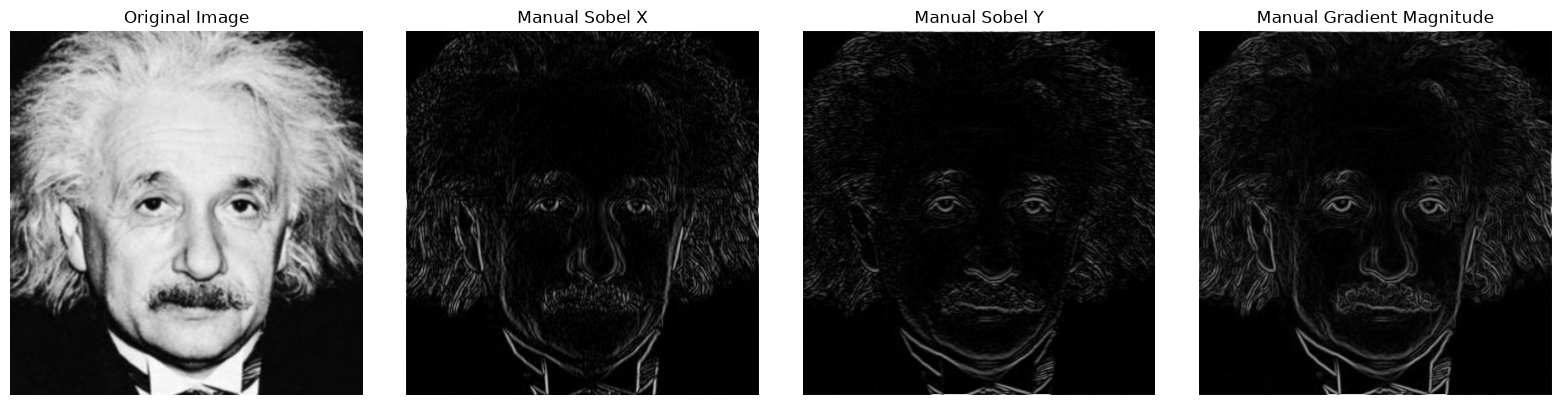

In [6]:
def manual_sobel_filter(image, kernel):

    h, w = image.shape
    kh, kw = kernel.shape

    pad_h = kh // 2
    pad_w = kw // 2

    padded = np.pad(image,((pad_h, pad_h), (pad_w, pad_w)),mode="constant")

    output = np.zeros_like(image,dtype=np.float32)

    for i in range(h):
        for j in range(w):

            region = padded[i:i + kh,j:j + kw]

            output[i, j] = np.sum(region * kernel)

    return output

gx = manual_sobel_filter(img_float, sobel_x)
gy = manual_sobel_filter(img_float, sobel_y)

magnitude = np.sqrt(gx**2 + gy**2)

gx_display = cv.normalize(np.abs(gx), None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)

gy_display = cv.normalize(np.abs(gy), None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)

magnitude_display = cv.normalize(magnitude, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)

plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(gx_display, cmap="gray")
plt.title("Manual Sobel X")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(gy_display, cmap="gray")
plt.title("Manual Sobel Y")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(magnitude_display, cmap="gray")
plt.title("Manual Gradient Magnitude")
plt.axis("off")

plt.tight_layout()
plt.show()

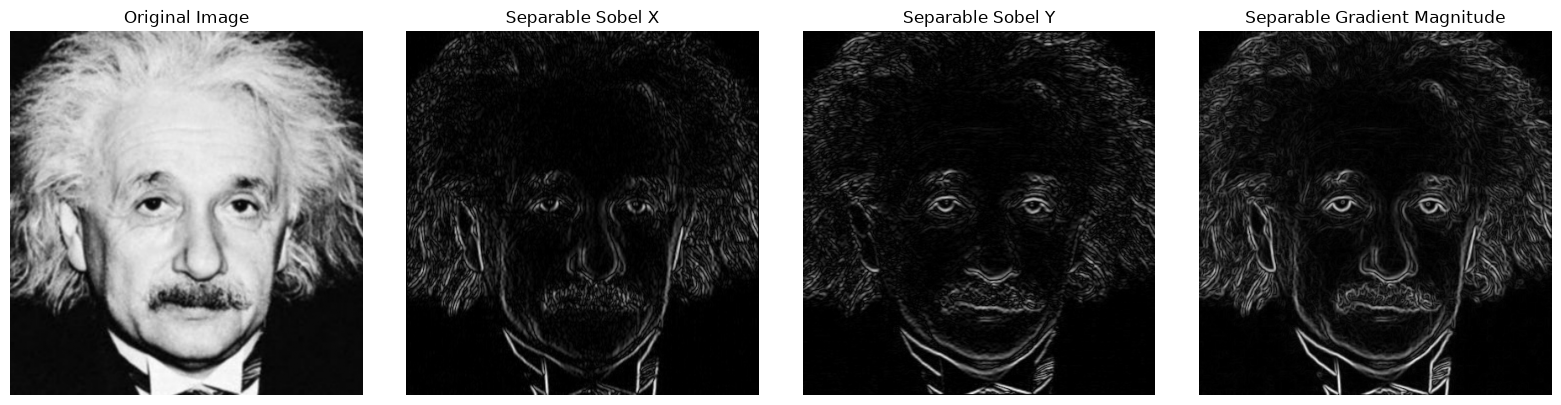

In [7]:
def separable_sobel_x(image):

    smoothing_kernel = np.array([
        [1],
        [2],
        [1]
    ], dtype=np.float32)

    derivative_kernel = np.array([[-1, 0, 1]], dtype=np.float32)

    temp = cv.filter2D(image,cv.CV_32F,smoothing_kernel)

    result = cv.filter2D(temp,cv.CV_32F,derivative_kernel)

    return result

def separable_sobel_y(image):

    smoothing_kernel = np.array([[1, 2, 1]], dtype=np.float32)

    derivative_kernel = np.array([
        [-1],
        [0],
        [1]
    ], dtype=np.float32)

    temp = cv.filter2D(image,cv.CV_32F,smoothing_kernel)

    result = cv.filter2D(temp,cv.CV_32F,derivative_kernel)

    return result

gx = separable_sobel_x(img_float)
gy = separable_sobel_y(img_float)
magnitude = np.sqrt(gx**2 + gy**2)

gx_display = cv.normalize(np.abs(gx), None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)

gy_display = cv.normalize(np.abs(gy), None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)

magnitude_display = cv.normalize(magnitude, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)

plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(gx_display, cmap="gray")
plt.title("Separable Sobel X")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(gy_display, cmap="gray")
plt.title("Separable Sobel Y")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(magnitude_display, cmap="gray")
plt.title("Separable Gradient Magnitude")
plt.axis("off")

plt.tight_layout()
plt.show()